# Módulo 4 — Engenharia de Atributos - Parte 02

## Prática
A prática consiste em manipular um dataset tabular contendo informações financeiras e comportamentais de clientes. A partir dessas variáveis, os alunos deverão construir novos atributos derivados, discretizar renda em faixas, aplicar diferentes estratégias de codificação categórica, identificar possíveis outliers, realizar transformações matemáticas e normalização de escala e analisar a relação entre variáveis por meio de correlação e informação mútua, avaliando como essas transformações modificam a estrutura informacional da base.

## Dataset
O arquivo dataset_clientes_transacoes_pequeno.csv representa um conjunto simplificado de clientes com informações demográficas, financeiras e comportamentais relacionadas ao uso de crédito. Cada linha corresponde a um cliente e descreve características como renda, limite disponível, volume de gastos e comportamento de pagamento, permitindo explorar técnicas básicas de engenharia de atributos e análise de variáveis em um cenário de previsão de inadimplência.

•	id_cliente: identificador único do cliente.
•	idade_cliente: idade do cliente (anos).
•	renda_mensal: renda mensal estimada do cliente.
•	limite_credito: limite de crédito disponível para o cliente.
•	valor_gasto_mes: valor total gasto pelo cliente no mês.
•	numero_transacoes: quantidade de transações realizadas no mês.
•	dias_atraso_pagamento: número de dias de atraso no pagamento da fatura.
•	inadimplente_prox_mes: indica se o cliente se tornou inadimplente no mês seguinte (1 = sim, 0 = não).


In [285]:
import pandas as pd

df = pd.read_csv("/content/dataset_clientes_transacoes_pequeno.csv", sep=None)

df.shape, df.head(40)

/tmp/ipykernel_583/470832322.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv("/content/dataset_clientes_transacoes_pequeno.csv", sep=None)


((44, 11),
    id_cliente  ano_mes  idade_cliente  renda_mensal  limite_credito  \
 0         C01  2024-01             53          8390           10000   
 1         C01  2024-02             53          8390           10000   
 2         C01  2024-03             53          8390           10000   
 3         C01  2024-04             53          8390           10000   
 4         C02  2024-01             54          9949           16000   
 5         C02  2024-02             54          9949           16000   
 6         C02  2024-03             54          9949           16000   
 7         C02  2024-04             54          9949           16000   
 8         C03  2024-01             27          6556           25000   
 9         C03  2024-02             27          6556           25000   
 10        C03  2024-03             27          6556           25000   
 11        C03  2024-04             27          6556           25000   
 12        C04  2024-01             52          8486 

### Pergunta
1.	Crie um novo atributo chamado gasto_medio_transacao, definido como a razão entre valor_gasto_mes e numero_transacoes, representando o valor médio gasto em cada transação realizada pelo cliente no mês.

2. Em seguida, construa um novo atributo por combinação entre variáveis, utilizando uma operação de diferença. Como sugestão, você pode criar a variável folga_limite (limite_credito - valor_gasto_mes). Isso é, quanto do limite de crédito ainda permanece disponível após os gastos do mês.

In [300]:
# Criar atributo gasto médio por transação (razão comportamental).
df["gasto_medio_transacao"] = df["valor_gasto_mes"] / df["numero_transacoes"]

# Visualizar
df[["valor_gasto_mes", "numero_transacoes", "gasto_medio_transacao"]]

,valor_gasto_mes,numero_transacoes,gasto_medio_transacao
0,6234,23,271.043478
1,4926,15,328.400000
2,12136,28,433.428571
3,2185,6,364.166667
4,5055,26,194.423077
5,3404,31,109.806452
6,3058,32,95.562500
7,1475,19,77.631579
8,3388,22,154.000000
9,1100,18,61.111111


In [287]:
# Conhecer valores estatísticos básicos do dataset.
df.describe()

,idade_cliente,renda_mensal,limite_credito,valor_gasto_mes,numero_transacoes,dias_atraso_pagamento,inadimplente_prox_mes,gasto_medio_transacao
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,44.363636,10837.909091,22272.727273,4215.909091,20.568182,4.795455,0.295455,280.432943
std,8.499223,5493.886335,10912.684398,2770.750212,9.138209,6.835542,0.461522,326.928880
min,27.000000,6242.000000,10000.000000,564.000000,5.000000,0.000000,0.000000,19.448276
25%,38.000000,7859.000000,14000.000000,2425.000000,13.000000,0.000000,0.000000,106.069196
50%,47.000000,8618.000000,20000.000000,3309.500000,19.000000,0.000000,0.000000,191.111538
75%,52.000000,12062.000000,28000.000000,5637.250000,28.000000,10.000000,1.000000,341.426282
max,54.000000,26345.000000,50000.000000,12136.000000,39.000000,24.000000,1.000000,2052.400000


### Pergunta
3. Crie a variável gasto_medio_cliente, calculando a média de valor_gasto_mes para cada id_cliente. Esse atributo deve representar o gasto médio histórico de cada cliente no dataset.

In [301]:
# Criar novo atributo agregado: gasto médio por cliente.
df["gasto_medio_cliente"] = df.groupby("id_cliente")["valor_gasto_mes"].transform("mean")

df[["id_cliente","valor_gasto_mes","gasto_medio_cliente"]]

,id_cliente,valor_gasto_mes,gasto_medio_cliente
0,C01,6234,6370.25
1,C01,4926,6370.25
2,C01,12136,6370.25
3,C01,2185,6370.25
4,C02,5055,3248.00
5,C02,3404,3248.00
6,C02,3058,3248.00
7,C02,1475,3248.00
8,C03,3388,2535.25
9,C03,1100,2535.25


In [289]:
df.head()

,id_cliente,ano_mes,idade_cliente,renda_mensal,limite_credito,valor_gasto_mes,numero_transacoes,categoria_profissional,regiao_cliente,dias_atraso_pagamento,inadimplente_prox_mes,gasto_medio_transacao,gasto_medio_cliente
0,C01,2024-01,53,8390,10000,6234,23,assalariado,norte,10,1,271.043478,6370.25
1,C01,2024-02,53,8390,10000,4926,15,assalariado,norte,10,1,328.400000,6370.25
2,C01,2024-03,53,8390,10000,12136,28,assalariado,norte,8,0,433.428571,6370.25
3,C01,2024-04,53,8390,10000,2185,6,assalariado,norte,12,1,364.166667,6370.25
4,C02,2024-01,54,9949,16000,5055,26,assalariado,norte,0,0,194.423077,3248.00


### Pergunta
4. Crie uma variável categórica chamada faixa_renda, discretizando (binning) renda_mensal em três categorias: baixa, média e alta renda.

In [290]:
# Criar variável categórica por discretização.
df["faixa_renda"] = pd.cut(df["renda_mensal"],
                           bins=[0,5000,10000,float("inf")],
                           labels=["baixa","media","alta"])

df.head()

,id_cliente,ano_mes,idade_cliente,renda_mensal,limite_credito,valor_gasto_mes,numero_transacoes,categoria_profissional,regiao_cliente,dias_atraso_pagamento,inadimplente_prox_mes,gasto_medio_transacao,gasto_medio_cliente,faixa_renda
0,C01,2024-01,53,8390,10000,6234,23,assalariado,norte,10,1,271.043478,6370.25,media
1,C01,2024-02,53,8390,10000,4926,15,assalariado,norte,10,1,328.400000,6370.25,media
2,C01,2024-03,53,8390,10000,12136,28,assalariado,norte,8,0,433.428571,6370.25,media
3,C01,2024-04,53,8390,10000,2185,6,assalariado,norte,12,1,364.166667,6370.25,media
4,C02,2024-01,54,9949,16000,5055,26,assalariado,norte,0,0,194.423077,3248.00,media


### Pergunta
5. Qual é a melhor escolha para a codificação da variável faixa de renda? Explique.

In [291]:
# Codificação original da variável categórica faixa de renda.
df["faixa_renda_ordem"] = df["faixa_renda"].map({
    "baixa": 1,
    "media": 2,
    "alta": 3
})

df.head(44)

,id_cliente,ano_mes,idade_cliente,renda_mensal,limite_credito,valor_gasto_mes,numero_transacoes,categoria_profissional,regiao_cliente,dias_atraso_pagamento,inadimplente_prox_mes,gasto_medio_transacao,gasto_medio_cliente,faixa_renda,faixa_renda_ordem
0,C01,2024-01,53,8390,10000,6234,23,assalariado,norte,10,1,271.043478,6370.25,media,2
1,C01,2024-02,53,8390,10000,4926,15,assalariado,norte,10,1,328.400000,6370.25,media,2
2,C01,2024-03,53,8390,10000,12136,28,assalariado,norte,8,0,433.428571,6370.25,media,2
3,C01,2024-04,53,8390,10000,2185,6,assalariado,norte,12,1,364.166667,6370.25,media,2
4,C02,2024-01,54,9949,16000,5055,26,assalariado,norte,0,0,194.423077,3248.00,media,2
5,C02,2024-02,54,9949,16000,3404,31,assalariado,norte,0,0,109.806452,3248.00,media,2
6,C02,2024-03,54,9949,16000,3058,32,assalariado,norte,0,0,95.562500,3248.00,media,2
7,C02,2024-04,54,9949,16000,1475,19,assalariado,norte,0,0,77.631579,3248.00,media,2
8,C03,2024-01,27,6556,25000,3388,22,empresario,norte,0,0,154.000000,2535.25,media,2
9,C03,2024-02,27,6556,25000,1100,18,empresario,norte,0,0,61.111111,2535.25,media,2


### Pergunta
6. Apenas para comparar, faça a codificação One-Hot da variável faixa de renda. Quantas colunas são criadas? Como a dimensionalidade cresceu? Como a biblioteca representa 1s e 0s nas colunas?

In [292]:
df = pd.get_dummies(df, columns=["faixa_renda"])
df.head()

,id_cliente,ano_mes,idade_cliente,renda_mensal,limite_credito,valor_gasto_mes,numero_transacoes,categoria_profissional,regiao_cliente,dias_atraso_pagamento,inadimplente_prox_mes,gasto_medio_transacao,gasto_medio_cliente,faixa_renda_ordem,faixa_renda_baixa,faixa_renda_media,faixa_renda_alta
0,C01,2024-01,53,8390,10000,6234,23,assalariado,norte,10,1,271.043478,6370.25,2,False,True,False
1,C01,2024-02,53,8390,10000,4926,15,assalariado,norte,10,1,328.400000,6370.25,2,False,True,False
2,C01,2024-03,53,8390,10000,12136,28,assalariado,norte,8,0,433.428571,6370.25,2,False,True,False
3,C01,2024-04,53,8390,10000,2185,6,assalariado,norte,12,1,364.166667,6370.25,2,False,True,False
4,C02,2024-01,54,9949,16000,5055,26,assalariado,norte,0,0,194.423077,3248.00,2,False,True,False


### Pergunta
7. Existem outliers, por exemplo, de renda mensal?

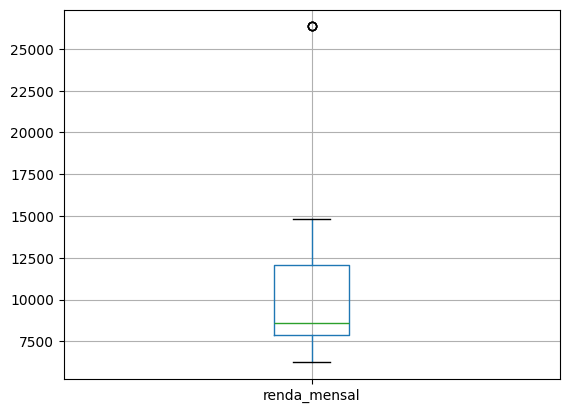

In [293]:
# Desenhar Box Plot é simples com Python.
ax = df.boxplot(column="renda_mensal")


Text(1.1, 14837, 'Bigode sup = 14837')

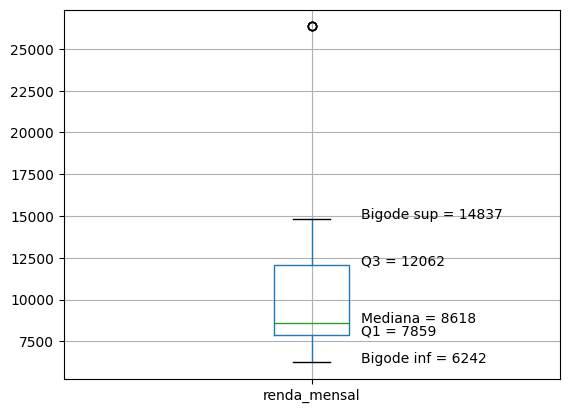

In [294]:
# Desenhar com alguns detalhes a mais (só para entender melhor).
q1 = df["renda_mensal"].quantile(0.25)
mediana = df["renda_mensal"].quantile(0.50)
q3 = df["renda_mensal"].quantile(0.75)

iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

bigode_inferior = df[df["renda_mensal"] >= limite_inferior]["renda_mensal"].min()
bigode_superior = df[df["renda_mensal"] <= limite_superior]["renda_mensal"].max()

# Desenhar boxplot.
ax = df.boxplot(column="renda_mensal")

# Anotações no gráfico.
ax.text(1.1, q1, f"Q1 = {q1:.0f}")
ax.text(1.1, mediana, f"Mediana = {mediana:.0f}")
ax.text(1.1, q3, f"Q3 = {q3:.0f}")
ax.text(1.1, bigode_inferior, f"Bigode inf = {bigode_inferior:.0f}")
ax.text(1.1, bigode_superior, f"Bigode sup = {bigode_superior:.0f}")

### Pergunta
8. Crie a variável log_renda aplicando log na variável renda_mensal. Compare os valores da variável original com os valores transformados. Qual é o valor do log da menor renda e qual é o valor do log da maior renda?

In [295]:
# Aplicar transformação logarítmica na renda.
import numpy as np
df["log_renda"] = np.log(df["renda_mensal"])

df[["renda_mensal","log_renda"]]

,renda_mensal,log_renda
0,8390,9.034796
1,8390,9.034796
2,8390,9.034796
3,8390,9.034796
4,9949,9.205227
5,9949,9.205227
6,9949,9.205227
7,9949,9.205227
8,6556,8.788136
9,6556,8.788136


### Pergunta
9. Normalize a variável renda_mensal utilizando Min-Max, de modo que seus valores passem a variar entre 0 e 1. Compare os valores antes e depois da transformação. Qual valor passa a representar a menor renda (mínimo) e qual valor passa a representar a maior renda (máximo) após a normalização?

In [296]:
# Normalização Min-Max.
df["renda_normalizada"] = (df["renda_mensal"] - df["renda_mensal"].min()) / (df["renda_mensal"].max() - df["renda_mensal"].min())

df[["renda_mensal","renda_normalizada"]]

,renda_mensal,renda_normalizada
0,8390,0.106850
1,8390,0.106850
2,8390,0.106850
3,8390,0.106850
4,9949,0.184400
5,9949,0.184400
6,9949,0.184400
7,9949,0.184400
8,6556,0.015620
9,6556,0.015620


### Pergunta
10. Calcule a matriz de correlação entre as variáveis numéricas do dataset. Existe algum par de variáveis com correlação muito alta (próxima de 1 ou -1)? O que isso pode indicar sobre a relação entre essas variáveis?

In [297]:
# Calcular matriz de correlação.
df.corr(numeric_only=True)

,idade_cliente,renda_mensal,limite_credito,valor_gasto_mes,numero_transacoes,dias_atraso_pagamento,inadimplente_prox_mes,gasto_medio_transacao,gasto_medio_cliente,faixa_renda_baixa,faixa_renda_media,faixa_renda_alta,log_renda,renda_normalizada
idade_cliente,1.000000,0.362103,-0.092363,0.197768,0.067344,0.055350,0.031260,0.079736,0.356397,NaN,-0.094969,0.094969,0.405524,0.362103
renda_mensal,0.362103,1.000000,0.824574,0.372243,-0.118339,-0.293555,-0.241770,0.275719,0.670818,NaN,-0.779133,0.779133,0.975358,1.000000
limite_credito,-0.092363,0.824574,1.000000,0.255551,-0.166000,-0.406400,-0.385772,0.227579,0.460528,NaN,-0.779221,0.779221,0.738766,0.824574
valor_gasto_mes,0.197768,0.372243,0.255551,1.000000,-0.109036,-0.161393,-0.122735,0.650592,0.554910,NaN,-0.355550,0.355550,0.384821,0.372243
numero_transacoes,0.067344,-0.118339,-0.166000,-0.109036,1.000000,0.048442,0.130209,-0.531601,-0.208237,NaN,0.078058,-0.078058,-0.065155,-0.118339
dias_atraso_pagamento,0.055350,-0.293555,-0.406400,-0.161393,0.048442,1.000000,0.896832,-0.199395,-0.115670,NaN,0.343953,-0.343953,-0.283237,-0.293555
inadimplente_prox_mes,0.031260,-0.241770,-0.385772,-0.122735,0.130209,0.896832,1.000000,-0.182699,-0.023042,NaN,0.284708,-0.284708,-0.215727,-0.241770
gasto_medio_transacao,0.079736,0.275719,0.227579,0.650592,-0.531601,-0.199395,-0.182699,1.000000,0.443881,NaN,-0.349034,0.349034,0.296281,0.275719
gasto_medio_cliente,0.356397,0.670818,0.460528,0.554910,-0.208237,-0.115670,-0.023042,0.443881,1.000000,NaN,-0.640735,0.640735,0.693485,0.670818
faixa_renda_baixa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


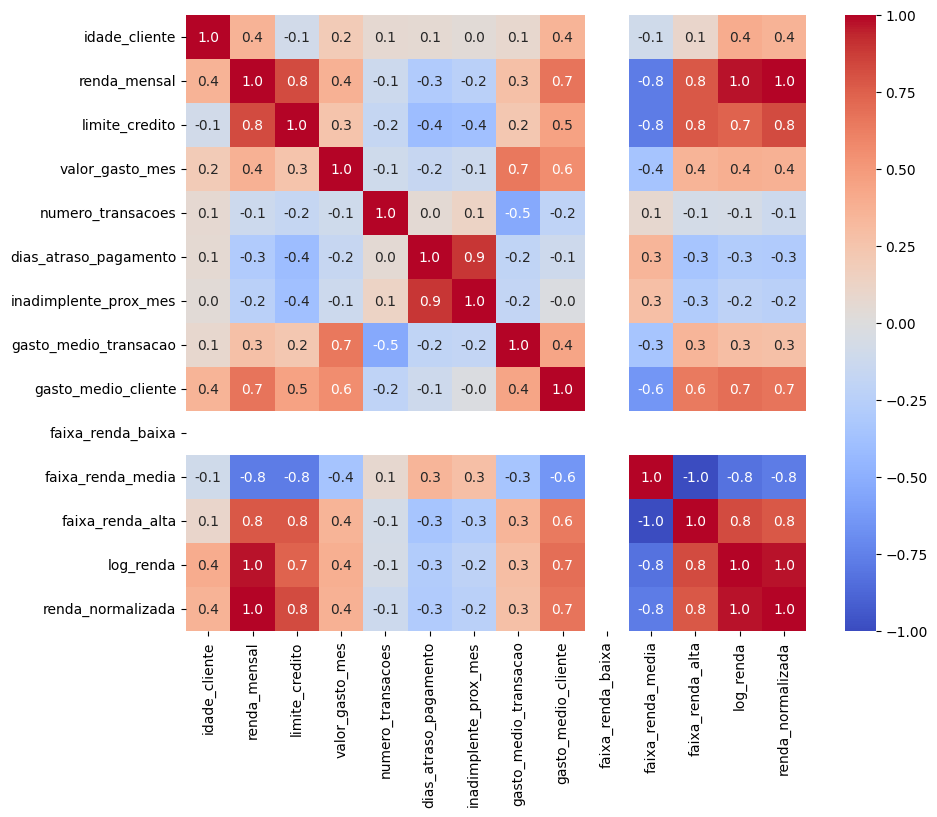

In [298]:
# Visualizar correlações.
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar correlações
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.show()

### Pergunta
11. Calcule a informação mútua entre as variáveis numéricas e o alvo inadimplente_prox_mes. Quais variáveis apresentam maior informação mútua e podem ser consideradas mais relevantes para prever a inadimplência?

In [299]:
# Cálculo da informação mútua.
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# selecionar apenas variáveis numéricas
X = df.select_dtypes(include=["number"]).drop(columns=["inadimplente_prox_mes"])
y = df["inadimplente_prox_mes"]

# calcular informação mútua
mi = mutual_info_classif(X, y)

# organizar resultado
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# adicionar informação do alvo
mi_scores.index.name = "Variável (comparada com alvo: inadimplente_prox_mes)"

mi_scores

,0
Variável (comparada com alvo: inadimplente_prox_mes),
dias_atraso_pagamento,0.556848
valor_gasto_mes,0.176635
renda_mensal,0.141434
renda_normalizada,0.136131
limite_credito,0.129956
idade_cliente,0.116806
log_renda,0.084616
gasto_medio_cliente,0.039990
numero_transacoes,0.000000


### Pergunta
12. Com base nos valores de informação mútua, qual variável parece ser mais informativa para prever a inadimplência? Existe alguma variável que aparentemente não contribui para explicar o alvo? O que isso sugere sobre a utilidade dessas variáveis para um modelo preditivo?